# 06 -- Сигнал и transaction costs

**Цель:** подготовить вход для бэктеста (Notebook 07).

**Что строим:**
1. **Mispricing signal** -- разница рыночного и предсказанного G-spread.
2. **Cross-sectional z-score и квинтили** -- для конструкции long-only top quintile.
3. **Roll (1984) bid-ask estimator** -- transaction costs из дневной автоковариации.
4. **Half-life via AR(1)** -- для time-stop в exit rule A (literature: Bertram 2010).
5. **Liquidity filter** -- volume_ma20 > 5M RUB/day.

**Источник сигнала:** `predictions_no_lag.csv` (R^2=0.524, MAE=3.91) -- чистый fair value, without g_spread_lag1 (with-lag дает momentum, не mispricing).

**Output:** `data/signal.csv` -- готовый вход для Notebook 07.

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,
})

np.random.seed(42)

ROOT = Path('..').resolve()
PREDICTIONS_PATH = ROOT / 'data' / 'predictions_no_lag.csv'
PANEL_PATH = ROOT / 'data' / 'panel_engineered.csv'
TRADES_PATH = ROOT / 'data' / 'trades_daily.csv'
SIGNAL_OUT = ROOT / 'data' / 'signal.csv'
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print(f'PREDICTIONS : {PREDICTIONS_PATH}')
print(f'PANEL       : {PANEL_PATH}')
print(f'TRADES      : {TRADES_PATH}')
print(f'SIGNAL_OUT  : {SIGNAL_OUT}')

PREDICTIONS : /repo/data/predictions_no_lag.csv
PANEL       : /repo/data/panel_engineered.csv
TRADES      : /repo/data/trades_daily.csv
SIGNAL_OUT  : /repo/data/signal.csv


## Часть 2. Загрузка данных

In [2]:
preds = pd.read_csv(PREDICTIONS_PATH, parse_dates=['date'])
print(f'predictions_no_lag: {preds.shape}')
print(f'  date range : {preds["date"].min().date()} .. {preds["date"].max().date()}')
print(f'  bonds      : {preds["isin"].nunique()}')
print(f'  columns    : {list(preds.columns)}')
preds.head()

predictions_no_lag: (277966, 5)
  date range : 2021-01-04 .. 2026-03-30
  bonds      : 965
  columns    : ['date', 'isin', 'g_spread_actual', 'g_spread_predicted', 'residual']


,date,isin,g_spread_actual,g_spread_predicted,residual
0,2021-01-04,RU000A0JSGV0,1.884855,2.094100,-0.209245
1,2021-01-04,RU000A0JSQ58,-5.934000,-1.454815,-4.479185
2,2021-01-04,RU000A0JT6B2,-1.585567,0.241742,-1.827309
3,2021-01-04,RU000A0JWRV9,1.546000,0.235900,1.310100
4,2021-01-04,RU000A0JWV63,3.034634,3.142752,-0.108118


In [3]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['date'], usecols=[
    'date', 'isin', 'volume_ma20', 'rating_numeric', 'sector', 'coupon_rate',
    'coupon_frequency', 'duration', 'time_to_maturity'
])
print(f'panel subset: {panel.shape}')
panel.head()

panel subset: (295569, 9)


,date,isin,duration,rating_numeric,sector,volume_ma20,coupon_rate,time_to_maturity,coupon_frequency
0,2020-01-03,RU000A0JSGV0,0.501370,NaN,NaN,565109.8,9.80,4557.0,2
1,2020-01-03,RU000A0JSQ58,0.071233,1.0,Электроэнергетика,200723.2,12.00,2756.0,2
2,2020-01-03,RU000A0JWV63,4.630137,3.0,Банки,1096529.9,14.25,NaN,2
3,2020-01-03,RU000A0JWYQ5,0.821918,6.0,Холдинги,84067.5,21.00,2492.0,2
4,2020-01-03,RU000A0JWZY6,0.134247,6.0,Холдинги,2385272.6,15.00,2506.0,4


In [4]:
trades = pd.read_csv(TRADES_PATH, parse_dates=['date'])
print(f'trades_daily: {trades.shape}')
print(f'  columns: {list(trades.columns)}')
trades.head()

trades_daily: (1239902, 7)
  columns: ['date', 'isin', 'close_price', 'yield_close', 'volume_rub', 'num_trades', 'duration']


,date,isin,close_price,yield_close,volume_rub,num_trades,duration
0,2019-01-03,RU000A0JQAM6,NaN,-45.39,0.0,0,71.0
1,2019-01-03,RU000A0JR4U9,NaN,60.04,0.0,0,NaN
2,2019-01-03,RU000A0JRJB8,NaN,10.87,0.0,0,NaN
3,2019-01-03,RU000A0JRJL7,NaN,10.71,0.0,0,NaN
4,2019-01-03,RU000A0JRU20,NaN,14.20,0.0,0,NaN


## Часть 3. Mispricing signal

**Конвенция знака:** `mispricing = actual - predicted`.
- `mispricing > 0` -- бумага торгуется с **большим спредом**, чем модель ожидает -> **недооценена** (yield слишком высокий) -> кандидат на **покупку**.
- `mispricing < 0` -- бумага торгуется с **меньшим спредом** -> **переоценена** -> кандидат на short (но мы long-only).

Затем считаем **cross-sectional z-score** на каждый день и присваиваем квинтили (Q1..Q5).

In [5]:
signal = preds.copy()
signal['mispricing'] = signal['g_spread_actual'] - signal['g_spread_predicted']

# Cross-sectional z-score per date
grp = signal.groupby('date')['mispricing']
signal['cs_mean'] = grp.transform('mean')
signal['cs_std']  = grp.transform('std')
signal['z_score'] = (signal['mispricing'] - signal['cs_mean']) / signal['cs_std']

# Quintile (1=most overvalued, 5=most undervalued)
def _quintile(s: pd.Series) -> pd.Series:
    if s.notna().sum() < 5:
        return pd.Series([np.nan] * len(s), index=s.index)
    return pd.qcut(s.rank(method='first'), 5, labels=False) + 1

signal['quintile'] = signal.groupby('date')['mispricing'].transform(_quintile)

print(f'Mispricing summary:')
print(signal['mispricing'].describe().round(3))
print()
print(f'Quintile counts (по строкам):')
print(signal['quintile'].value_counts().sort_index())

Mispricing summary:
count    277966.000
mean          0.440
std          22.702
min        -510.279
25%          -0.927
50%          -0.074
75%           0.716
max         923.708
Name: mispricing, dtype: float64

Quintile counts (по строкам):
quintile
1    56087
2    55346
3    55357
4    55346
5    55830
Name: count, dtype: int64


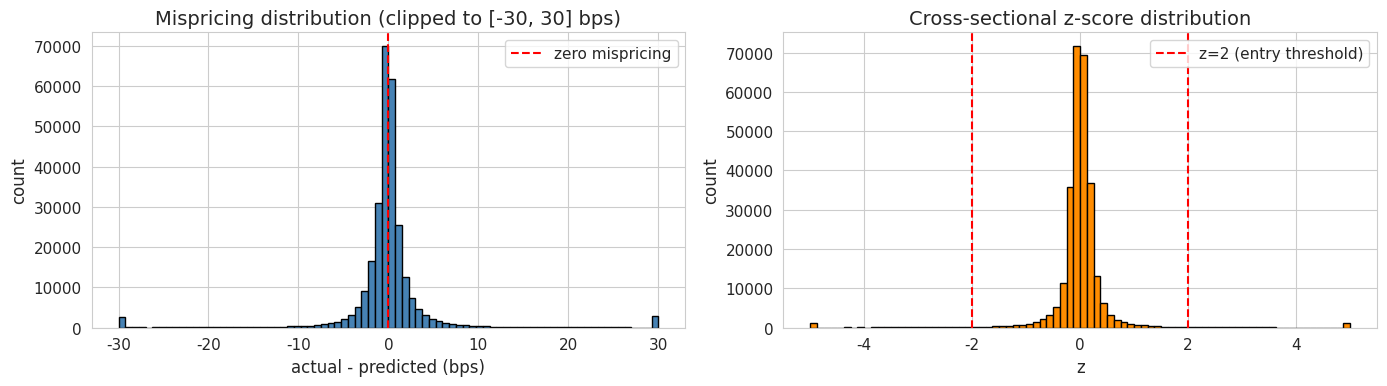

Saved figures/06_mispricing_distribution.png


In [6]:
# График: распределение mispricing
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(signal['mispricing'].clip(-30, 30), bins=80, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='zero mispricing')
axes[0].set_title('Mispricing distribution (clipped to [-30, 30] bps)')
axes[0].set_xlabel('actual - predicted (bps)')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].hist(signal['z_score'].clip(-5, 5).dropna(), bins=80, color='darkorange', edgecolor='black')
axes[1].axvline(2, color='red', linestyle='--', label='z=2 (entry threshold)')
axes[1].axvline(-2, color='red', linestyle='--')
axes[1].set_title('Cross-sectional z-score distribution')
axes[1].set_xlabel('z')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '06_mispricing_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved figures/06_mispricing_distribution.png')

In [7]:
# Sanity: средний mispricing по квинтилям -- должен быть монотонным
qstats = signal.groupby('quintile').agg(
    n=('mispricing', 'size'),
    mean_mispricing=('mispricing', 'mean'),
    mean_zscore=('z_score', 'mean'),
    mean_actual=('g_spread_actual', 'mean'),
    mean_predicted=('g_spread_predicted', 'mean'),
).round(3)
print('Sanity check: stats by quintile (Q1=overvalued, Q5=undervalued)')
print(qstats)

Sanity check: stats by quintile (Q1=overvalued, Q5=undervalued)
              n  mean_mispricing  mean_zscore  mean_actual  mean_predicted
quintile                                                                  
1         56087           -7.424       -0.626        4.966          12.390
2         55346           -0.751       -0.077        3.720           4.472
3         55357           -0.040        0.004        4.052           4.092
4         55346            0.702        0.084        5.099           4.398
5         55830            9.737        0.619       20.685          10.947


## Часть 4. Roll (1984) bid-ask estimator

**Идея:** в эффективном рынке при наличии bid-ask spread `s`, последовательные returns имеют отрицательную автоковариацию: `cov(r_t, r_{t-1}) = -s^2 / 4`.
Отсюда: `s = 2 * sqrt(-cov)`, если `cov < 0`.

**Окно:** 60 торговых дней.

**Fallback:** если `cov >= 0` (положительная автокорреляция, неликвидный спред), используем 50 bps round-trip -- консервативная медиана из литературы по корп облигациям РФ.

In [8]:
FALLBACK_BPS = 0.0050  # 50 bps round-trip
WINDOW = 60

# Используем close_price для log-returns
trades_sorted = trades.sort_values(['isin', 'date']).copy()
trades_sorted['log_price'] = np.log(trades_sorted['close_price'])
trades_sorted['ret'] = trades_sorted.groupby('isin')['log_price'].diff()

# Lag returns within each isin
trades_sorted['ret_lag'] = trades_sorted.groupby('isin')['ret'].shift(1)

# Rolling covariance per isin
def _roll_cov(grp: pd.DataFrame) -> pd.Series:
    return grp['ret'].rolling(WINDOW, min_periods=WINDOW // 2).cov(grp['ret_lag'])

trades_sorted['cov_lag1'] = trades_sorted.groupby('isin', group_keys=False).apply(_roll_cov)

# Roll spread (round-trip, в долях цены)
trades_sorted['roll_spread'] = np.where(
    trades_sorted['cov_lag1'] < 0,
    2 * np.sqrt(-trades_sorted['cov_lag1']),
    np.nan,
)

# Fallback
trades_sorted['roll_spread_filled'] = trades_sorted['roll_spread'].fillna(FALLBACK_BPS)

print(f'Roll spread coverage:')
valid = trades_sorted['roll_spread'].notna().sum()
total = len(trades_sorted)
print(f'  valid (cov<0)    : {valid:>10,}  ({valid / total:.1%})')
print(f'  fallback (50 bps): {total - valid:>10,}  ({1 - valid / total:.1%})')
print()
print('Roll spread distribution (where valid, bps):')
print((trades_sorted['roll_spread'].dropna() * 10000).describe().round(1))

Roll spread coverage:
  valid (cov<0)    :    489,532  (39.5%)
  fallback (50 bps):    750,370  (60.5%)

Roll spread distribution (where valid, bps):
count    489532.0
mean         73.4
std          99.5
min           0.1
25%          26.5
50%          45.3
75%          81.5
max        3148.7
Name: roll_spread, dtype: float64


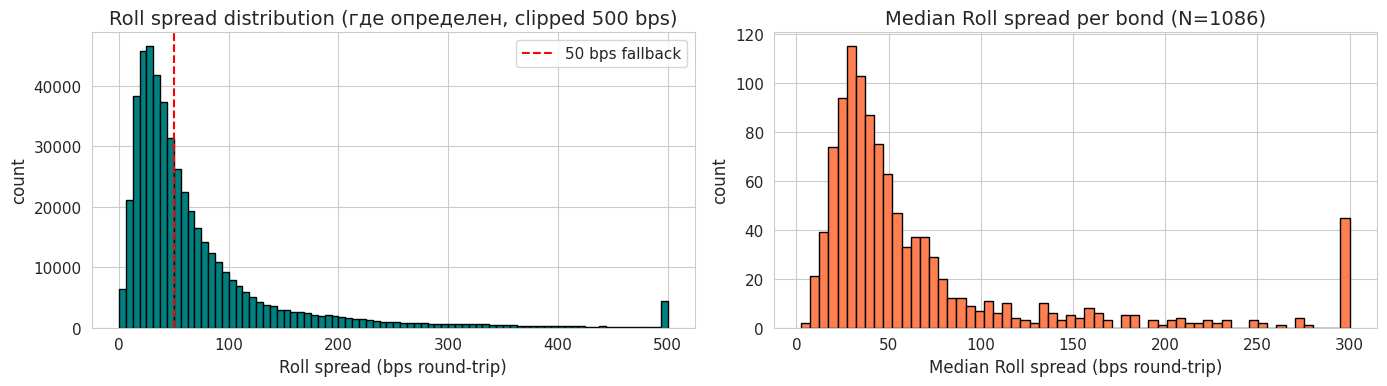

Saved figures/06_roll_spread.png


In [9]:
# График: распределение Roll spread
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

valid_bps = (trades_sorted['roll_spread'].dropna() * 10000).clip(0, 500)
axes[0].hist(valid_bps, bins=80, color='teal', edgecolor='black')
axes[0].axvline(50, color='red', linestyle='--', label='50 bps fallback')
axes[0].set_title(f'Roll spread distribution (где определен, clipped 500 bps)')
axes[0].set_xlabel('Roll spread (bps round-trip)')
axes[0].set_ylabel('count')
axes[0].legend()

# Per-isin median
per_isin = trades_sorted.groupby('isin')['roll_spread'].median().dropna() * 10000
axes[1].hist(per_isin.clip(0, 300), bins=60, color='coral', edgecolor='black')
axes[1].set_title(f'Median Roll spread per bond (N={len(per_isin)})')
axes[1].set_xlabel('Median Roll spread (bps round-trip)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_roll_spread.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved figures/06_roll_spread.png')

## Часть 5. Half-life via AR(1)

**Модель:** для каждой бумаги rolling AR(1) на её spread:
`g_spread_t = alpha + beta * g_spread_{t-1} + eps`

**Half-life:** `t_half = ln(2) / (-ln(beta))`, если `0 < beta < 1`.

**Окно:** 120 торговых дней (~6 мес) -- баланс между точностью оценки и реактивностью к смене режима.

**Литература:** Bierens, Huang, Kong (2003) для половины жизни кредитных спредов; Bertram (2010) для оптимальной точки выхода из mean-reverting позиции.

In [10]:
# Half-life считаем по panel (там g_spread есть для всех дней с торгами)
panel_full = pd.read_csv(PANEL_PATH, parse_dates=['date'], usecols=['date', 'isin', 'g_spread'])
panel_full = panel_full.dropna(subset=['g_spread']).sort_values(['isin', 'date']).copy()
panel_full['g_spread_lag1'] = panel_full.groupby('isin')['g_spread'].shift(1)

WIN_HL = 120

def _rolling_ar1_beta(grp: pd.DataFrame, win: int = WIN_HL) -> pd.Series:
    y = grp['g_spread'].values
    x = grp['g_spread_lag1'].values
    out = np.full(len(y), np.nan)
    for i in range(win, len(y)):
        ys = y[i - win:i]
        xs = x[i - win:i]
        mask = np.isfinite(ys) & np.isfinite(xs)
        if mask.sum() < win // 2:
            continue
        ys, xs = ys[mask], xs[mask]
        var = ((xs - xs.mean()) ** 2).sum()
        if var <= 0:
            continue
        cov = ((xs - xs.mean()) * (ys - ys.mean())).sum()
        out[i] = cov / var
    return pd.Series(out, index=grp.index)

print('Computing rolling AR(1) beta per bond... (~1-2 min)')
panel_full['ar1_beta'] = panel_full.groupby('isin', group_keys=False).apply(_rolling_ar1_beta)

# Half-life only for 0 < beta < 1
panel_full['half_life_days'] = np.where(
    (panel_full['ar1_beta'] > 0) & (panel_full['ar1_beta'] < 1),
    np.log(2) / (-np.log(panel_full['ar1_beta'].clip(upper=0.999))),
    np.nan,
)

print(f'AR(1) beta coverage: {panel_full["ar1_beta"].notna().sum():,} / {len(panel_full):,}')
print(f'Half-life coverage : {panel_full["half_life_days"].notna().sum():,}')
print()
print('Half-life distribution (days):')
print(panel_full['half_life_days'].describe().round(1))

Computing rolling AR(1) beta per bond... (~1-2 min)


AR(1) beta coverage: 199,729 / 295,569
Half-life coverage : 193,973

Half-life distribution (days):
count    193973.0
mean         11.6
std          36.5
min           0.1
25%           2.2
50%           4.5
75%          10.4
max         692.8
Name: half_life_days, dtype: float64


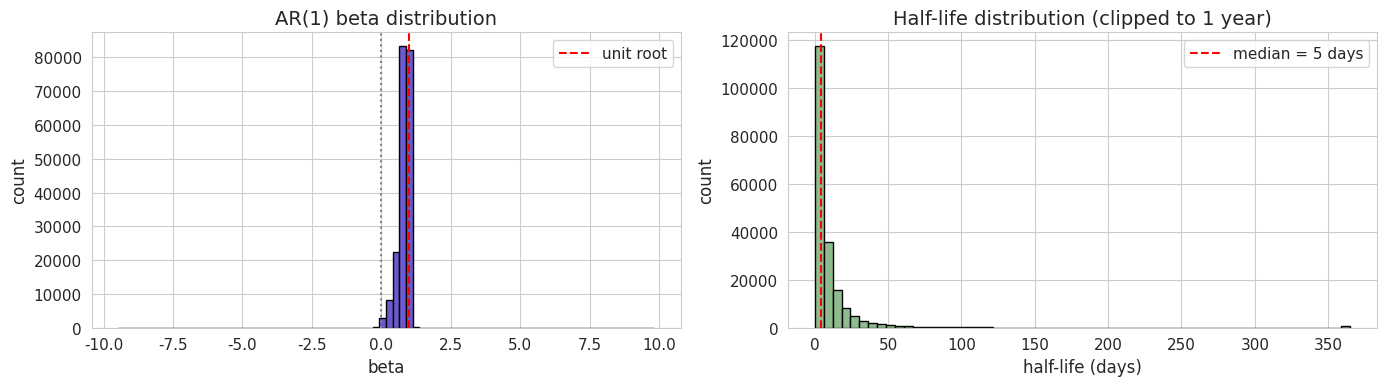

Saved figures/06_half_life.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(panel_full['ar1_beta'].dropna(), bins=80, color='slateblue', edgecolor='black')
axes[0].axvline(1.0, color='red', linestyle='--', label='unit root')
axes[0].axvline(0.0, color='gray', linestyle=':')
axes[0].set_title('AR(1) beta distribution')
axes[0].set_xlabel('beta')
axes[0].set_ylabel('count')
axes[0].legend()

hl = panel_full['half_life_days'].dropna().clip(0, 365)
axes[1].hist(hl, bins=60, color='darkseagreen', edgecolor='black')
axes[1].axvline(hl.median(), color='red', linestyle='--', label=f'median = {hl.median():.0f} days')
axes[1].set_title('Half-life distribution (clipped to 1 year)')
axes[1].set_xlabel('half-life (days)')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '06_half_life.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved figures/06_half_life.png')

## Часть 6. Liquidity filter

**Правило:** в Q5 включаем только бумаги с `volume_ma20 > 5M RUB/day`.

Это убирает абсолютно неликвидные имена, по которым реальная торговля невозможна (даже на 10M RUB позиции). Порог выбран на основе распределения волюмов в EDA.

In [12]:
LIQUIDITY_MIN_RUB = 5_000_000

panel['tradable'] = panel['volume_ma20'] > LIQUIDITY_MIN_RUB
print(f'Liquidity filter (volume_ma20 > {LIQUIDITY_MIN_RUB:,} RUB):')
print(f'  tradable rows : {panel["tradable"].sum():,} / {len(panel):,} ({panel["tradable"].mean():.1%})')

# По датам: сколько бумаг tradable
daily_tradable = panel.groupby('date')['tradable'].sum()
print(f'\nMean tradable bonds per day  : {daily_tradable.mean():.0f}')
print(f'Min tradable bonds per day   : {daily_tradable.min()}')
print(f'Max tradable bonds per day   : {daily_tradable.max()}')

Liquidity filter (volume_ma20 > 5,000,000 RUB):
  tradable rows : 120,672 / 295,569 (40.8%)

Mean tradable bonds per day  : 78
Min tradable bonds per day   : 1
Max tradable bonds per day   : 295


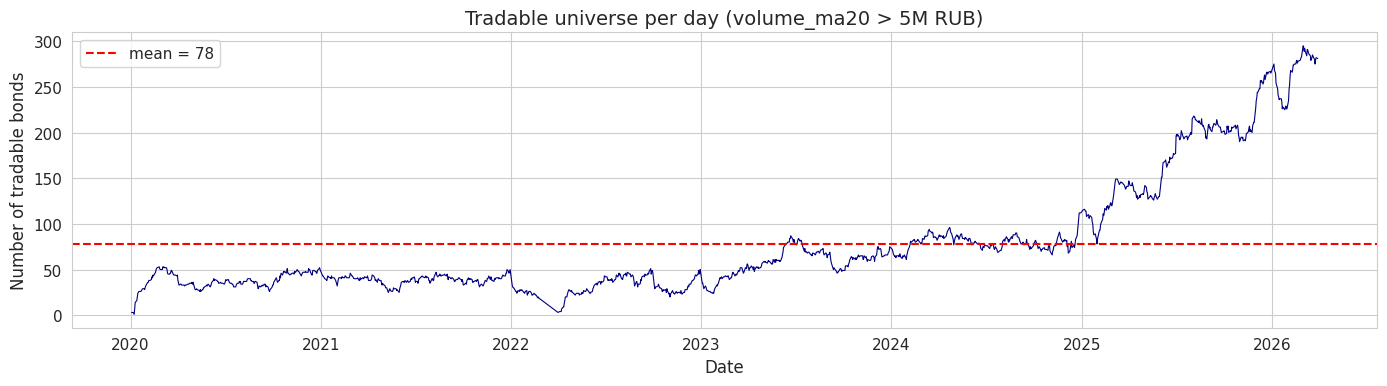

Saved figures/06_tradable_universe.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_tradable.index, daily_tradable.values, color='navy', linewidth=0.8)
ax.axhline(daily_tradable.mean(), color='red', linestyle='--', 
           label=f'mean = {daily_tradable.mean():.0f}')
ax.set_title(f'Tradable universe per day (volume_ma20 > {LIQUIDITY_MIN_RUB / 1e6:.0f}M RUB)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of tradable bonds')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06_tradable_universe.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved figures/06_tradable_universe.png')

## Часть 7. Слияние и сохранение signal.csv

Объединяем всё в одну таблицу:
- predictions + mispricing + z_score + quintile (из части 3)
- close_price + roll_spread (из части 4)
- half_life_days (из части 5)
- tradable + панельные характеристики (из части 6)

Output: `data/signal.csv`

In [14]:
# 1) База: signal (predictions + mispricing)
out = signal[['date', 'isin', 'g_spread_actual', 'g_spread_predicted',
              'mispricing', 'z_score', 'quintile']].copy()

# 2) Roll spread + close_price из trades
trades_merge = trades_sorted[['date', 'isin', 'close_price', 'roll_spread', 'roll_spread_filled']]
out = out.merge(trades_merge, on=['date', 'isin'], how='left')

# 3) Half-life
hl_merge = panel_full[['date', 'isin', 'half_life_days', 'ar1_beta']]
out = out.merge(hl_merge, on=['date', 'isin'], how='left')

# 4) Liquidity + панельные
out = out.merge(panel, on=['date', 'isin'], how='left')

# Заполняем roll_spread fallback'ом везде, где NaN
FALLBACK_BPS = 0.0050
out['roll_spread_used'] = out['roll_spread'].fillna(FALLBACK_BPS)
out['roll_spread_used'] = out['roll_spread_used'].clip(lower=0.0010, upper=0.0500)  # 10..500 bps

# Half-life fallback: если не определена, ставим медиану по universe (или 90 дней)
hl_median = out['half_life_days'].median()
if not np.isfinite(hl_median):
    hl_median = 90.0
out['half_life_used'] = out['half_life_days'].fillna(hl_median).clip(lower=5, upper=365)

print(f'Final signal table: {out.shape}')
print(f'  date range : {out["date"].min().date()} .. {out["date"].max().date()}')
print(f'  bonds      : {out["isin"].nunique()}')
print()
print('Coverage:')
for col in ['mispricing', 'z_score', 'quintile', 'roll_spread', 'half_life_days',
            'tradable', 'volume_ma20', 'close_price']:
    cov = out[col].notna().sum() / len(out)
    print(f'  {col:25s}: {cov:.1%}')

Final signal table: (277966, 22)
  date range : 2021-01-04 .. 2026-03-30
  bonds      : 965

Coverage:
  mispricing               : 100.0%
  z_score                  : 100.0%
  quintile                 : 100.0%
  roll_spread              : 73.5%
  half_life_days           : 67.8%
  tradable                 : 100.0%
  volume_ma20              : 100.0%
  close_price              : 99.7%


In [15]:
out.to_csv(SIGNAL_OUT, index=False)
print(f'Saved -> {SIGNAL_OUT}')
print(f'Size  : {SIGNAL_OUT.stat().st_size / 1e6:.1f} MB')
print()
print('Sample rows:')
out.head()

Saved -> /repo/data/signal.csv
Size  : 79.1 MB

Sample rows:


,date,isin,g_spread_actual,g_spread_predicted,mispricing,z_score,quintile,close_price,roll_spread,roll_spread_filled,...,duration,rating_numeric,sector,volume_ma20,coupon_rate,time_to_maturity,coupon_frequency,tradable,roll_spread_used,half_life_used
0,2021-01-04,RU000A0JSGV0,1.884855,2.094100,-0.209245,-0.138016,2,NaN,0.000869,0.000869,...,0.495890,NaN,NaN,6936597.080,9.80,4190.0,2,True,0.001000,5.000000
1,2021-01-04,RU000A0JSQ58,-5.934000,-1.454815,-4.479185,-4.302636,1,100.45,0.002781,0.002781,...,0.063014,1.0,Электроэнергетика,2129910.160,12.00,2389.0,2,False,0.002781,5.000000
2,2021-01-04,RU000A0JT6B2,-1.585567,0.241742,-1.827309,-1.716170,1,101.84,0.004029,0.004029,...,0.257534,1.0,Институты развития и государственные агентства,877212.730,14.21,4280.0,2,False,0.004029,5.000000
3,2021-01-04,RU000A0JWRV9,1.546000,0.235900,1.310100,1.343854,5,100.27,0.002465,0.002465,...,0.145205,1.0,Связь и телекоммуникация,24530.720,15.00,3875.0,2,False,0.002465,5.000000
4,2021-01-04,RU000A0JWV63,3.034634,3.142752,-0.108118,-0.039383,3,127.77,0.001951,0.001951,...,4.180822,3.0,Банки,7519596.555,14.25,NaN,2,True,0.001951,8.487937


## Часть 8. Итоги

**Что готово для Notebook 07:**
- `signal.csv` -- mispricing, z-score, quintile per (date, isin)
- Roll spread per (date, isin) с fallback на 50 bps
- Half-life per (date, isin) с fallback на медиану
- Liquidity flag `tradable`
- Close prices для расчёта returns в бэктесте

**Дальше (Notebook 07):**
- Конструкция long-only top quintile portfolio
- Три exit rules (C/A/D)
- Main period 2021-01..2025-09 + clean holdout 2025-10..2026-03
- Метрики: Sharpe, Sortino, MaxDD, Calmar, IR vs RUCBITR